# Project 2: Medical Route Optimization

This notebook demonstrates the Genetic Algorithm solution for the Vehicle Routing Problem (VRP) in a medical delivery context.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import random
from src.models.location import Location
from src.models.vehicle import Vehicle
from src.algorithms.genetic_optimizer import GeneticOptimizer
from src.utils.plotter import Plotter
from src.llm.report_generator import ReportGenerator
from src.utils.data_loader import DataLoader

/Users/rogeriobrumhermany/Projects/fiap/tsp/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# 1. Define Problem Data
depot = Location(0, 50, 50, "Central Depot", type='depot')

NUM_LOCATIONS = 60

locations = DataLoader.load_data(limit=NUM_LOCATIONS, data_dir='../data')

# Create Fleet
# Estimate required capacity
deliveries = [l for l in locations if getattr(l, 'type', 'delivery') == 'delivery']
total_demand = sum(l.demand for l in deliveries)
num_vehicles = 6

fleet = []
total_capacity = 0
total_distance = 0
for i in range(num_vehicles):
    capacity = random.randint(3, 6)
    total_capacity += capacity
    max_distance = random.randint(100, 200)
    total_distance += max_distance
    fleet.append(Vehicle(id=i+1, capacity=capacity, max_distance=max_distance))

print(f"Loaded {NUM_LOCATIONS} locations from dataset and {len(locations) - NUM_LOCATIONS} gas stations.")
print(f"Created Fleet of {len(fleet)} vehicles with total load capacity of {total_capacity} and total autonomy distance of {total_distance}")
print("Fleet: ")
for vehicle in fleet:
    print(f"Vehicle {vehicle.id} has a capacity of {vehicle.capacity} and a max distance of {vehicle.max_distance}")

Loaded 60 locations from dataset and 10 gas stations.
Created Fleet of 6 vehicles with total load capacity of 31 and total autonomy distance of 899
Fleet: 
Vehicle 1 has a capacity of 6 and a max distance of 161
Vehicle 2 has a capacity of 6 and a max distance of 178
Vehicle 3 has a capacity of 6 and a max distance of 144
Vehicle 4 has a capacity of 4 and a max distance of 129
Vehicle 5 has a capacity of 6 and a max distance of 122
Vehicle 6 has a capacity of 3 and a max distance of 165


In [3]:
# 2. Run Genetic Algorithm
# Adjust generations/pop_size based on problem size if needed
locations_times_vehicles = NUM_LOCATIONS * num_vehicles
generations = locations_times_vehicles * 4 
population_size = 60
early_stopping_rounds = 50


optimizer = GeneticOptimizer(locations, depot, fleet, generations=generations, population_size=population_size, early_stopping_rounds=early_stopping_rounds, priority_weight=0.1)
best_routes, best_dist, fitness_history = optimizer.run()

print(f"Best Total Distance: {best_dist:.2f}")

Stopping early at generation 411 due to no improvement for 50 rounds.
Best Total Distance: 1509.65


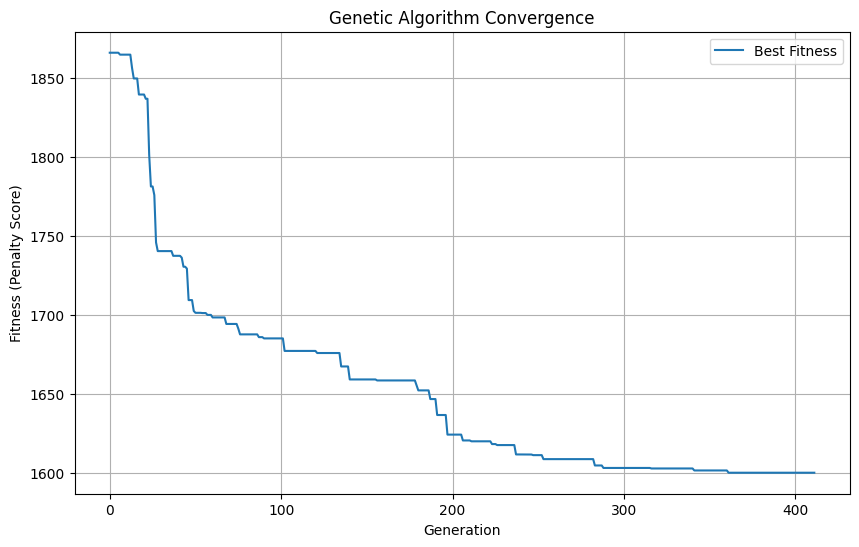

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(fitness_history, label='Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.xlabel('Generation')
plt.ylabel('Fitness (Penalty Score)')
plt.grid(True)
plt.legend()
plt.show()

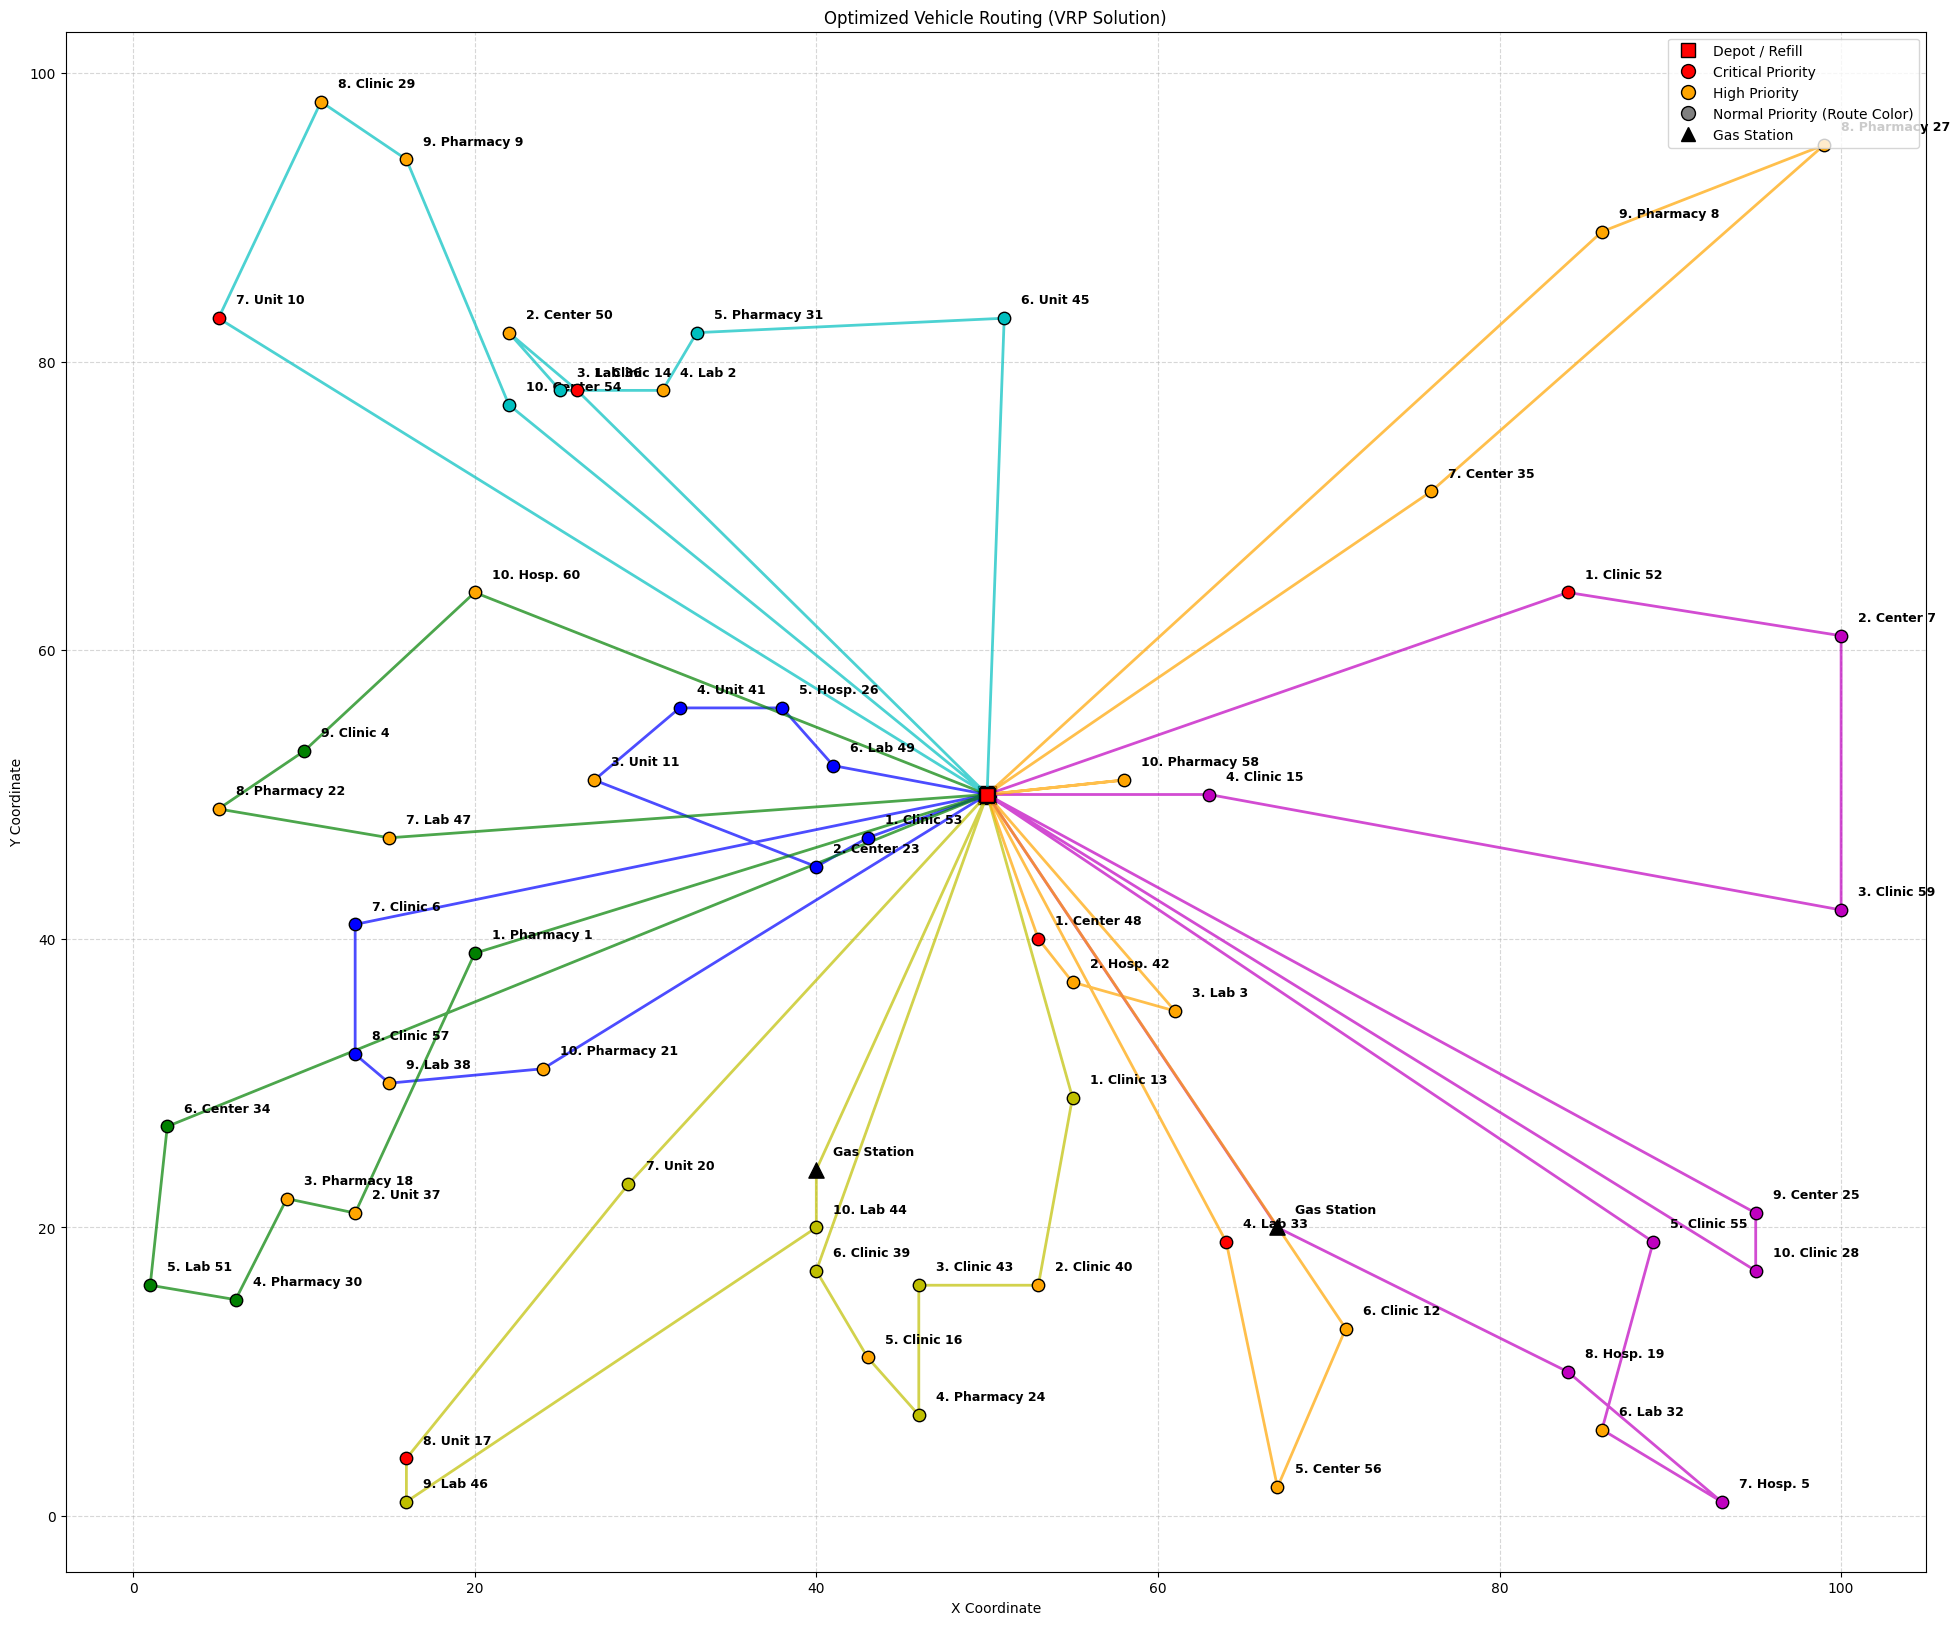

In [5]:
# 3. Visualize Solution
Plotter.plot_solution(best_routes, depot)

In [6]:
# 4. Generate LLM Report
llm = ReportGenerator()

print("Generating Instructions for Drivers...\n")

max_reports = 3

for i, route in enumerate(best_routes[:max_reports]):
    print(llm.generate_driver_instructions(i, route))
    print("\n" + "="*40 + "\n")

if len(best_routes) > max_reports:
    print(f"... and {len(best_routes) - max_reports} more routes.")

Loading local model: Qwen/Qwen2.5-3B-Instruct...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk.
Device set to use mps


Model loaded successfully.
Generating Instructions for Drivers...

Hey there Driver,

Good day! 

Here's your plan for today:

- Clinic 53 (Normal)
- Center 23 (Normal)
- Unit 11 (Immediate)
- Unit 41 (Normal)
- Hosp. 26 (Normal)
- Lab 49 (Normal)

Then head to:

- Central Depot: Clinic 6 (Normal)
- Central Depot: Clinic 57 (Normal)
- Central Depot: Lab 38 (Immediate)
- Central Depot: Pharmacy 21 (Immediate)

Be safe out there!

Driver buddy.


Hey there!

Good morning! Here’s your day:

- Pharmacy 1 (Normal)
- Unit 37 (Immediate)
- Pharmacy 18 (Immediate)
- Pharmacy 30 (Normal)
- Lab 51 (Normal)
- Center 34 (Normal)

Central Depot:
- Lab 47 (Immediate)
- Pharmacy 22 (Immediate)
- Clinic 4 (Normal)
- Hosp. 60 (Immediate)

Central Depot again:

- Lab 47 (Immediate)
- Pharmacy 22 (Immediate)
- Clinic 4 (Normal)
- Hosp. 60 (Immediate)

Stay safe out there!

Night owl!


Hey there,

Hope you're doing good! Here's your run for today:

- Clinic 14 (High Priority)
- Center 50 (Immediate Prior